Here we learn how to apply logistic regression to some real-life problems.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [17]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Change column names to lower case and replace spaces with underscores
df[df.columns[df.dtypes == 'object']] = df[df.columns[df.dtypes == 'object']].apply(lambda x: x.str.lower().str.replace(' ', '_'))
df.rename(columns=lambda x: x.lower().replace(' ', '_'), inplace=True)

In [19]:
df.isna().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [20]:
df.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges         object
churn                object
dtype: object

In this case, one of the data series (the totalcharges column) is full of numbers but they were loaded as objects and cannot be used to feed a model yet. We have to convert them to float. In addition, for the target variable, we will change the output from NO and YES to 0 and 1, respectively.

In [4]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.churn = df.churn.map({'yes': 1, 'no': 0})

In [22]:
df.totalcharges.head()

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: totalcharges, dtype: float64

Now, we look at the distribution of the target variable.

In [5]:
import seaborn as sns

<Axes: xlabel='churn'>

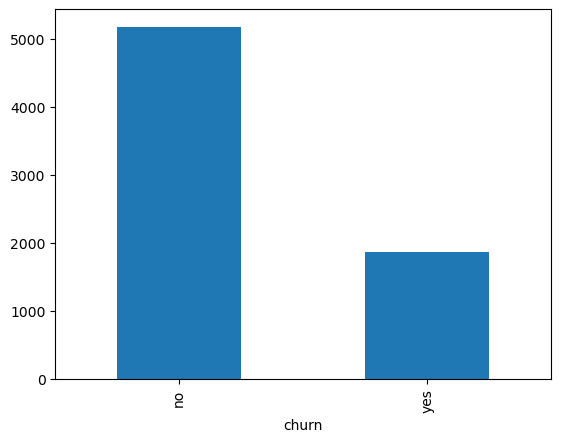

In [27]:
df.churn.value_counts().plot(kind='bar')

In [29]:
df.churn.value_counts()/df.churn.value_counts().sum()

churn
no     0.73463
yes    0.26537
Name: count, dtype: float64

Now, let's dive into some metrics commonly used in business environments.

Churn rate: we compare the target variable statistics in a subgroup of a determined category of a categorical variable, with the overall target variable statistic. This is usefull to look for correlations that lead to determine how likely is that a determined subgroup gets certain target value.

In [7]:
globmean = df.churn.mean()
malemean = df.churn[df["gender"] == "male"].mean()
print(globmean - malemean)

0.0037664952662697093


In the above example, we compared the global mean of the target variable with the mean of that same variable in the group of male customers. The result implies that the effect we are studying (churning the company, which is labeled as 1), is slightly less present in that subgroup than in general. Since the difference in minimal, we can say that there is no correlation between gender and the condition of staying or not in the company.

Another usefull metric is the churn ratio, which is the ratio between these relative and global averages, and provides a notion in terms of relative quantities.

In [9]:
print(malemean/globmean)

0.9858066205669676


Even though that metric is usefull to look for correlations between two categories, for features with many outputs it does not provide full information. In this scenario, a more usefull metric is the mutual information between two variables:
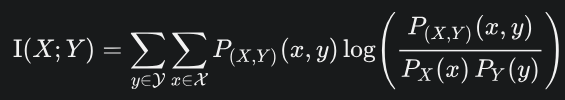

It gives zero if X and Y are independent, and is maximum if there is a deterministic relation between them.

In [6]:
from sklearn.metrics import mutual_info_score

For example, if we look at the "contract" variable, computing the mutual information between this and the "churn" variable tells us that there is a non-negligible correlation between them.

In [7]:
mutual_info_score(df.churn, df.contract)

0.09845305342598942

In [15]:
df.contract.unique()

array(['month-to-month', 'one_year', 'two_year'], dtype=object)

<Axes: xlabel='contract'>

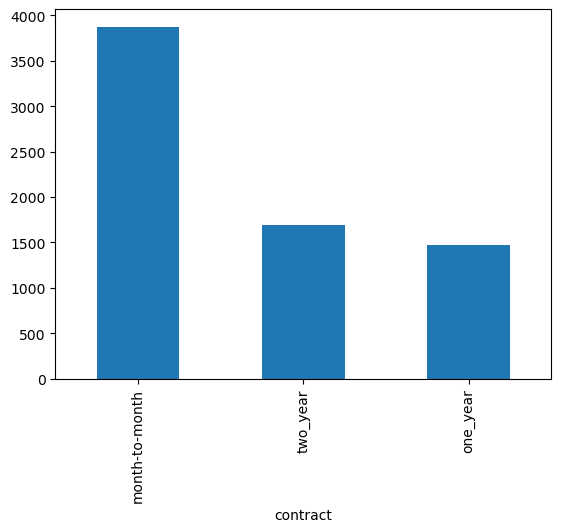

In [9]:
df.contract.value_counts().plot(kind='bar')

In [16]:
globmean = df.churn.mean()
print("Subgroup | Churn ratio")
for ctr in df.contract.unique():
    subgrpmean = df.churn[df["contract"] == ctr].mean()
    print(f"{ctr} | ", subgrpmean/globmean)

Subgroup | Churn ratio
month-to-month |  1.609439583009717
one_year |  0.4246720984861445
two_year |  0.10671363703082902


These results show that the effect we are analyzing (churning the company) is much more present in people with shorter-term contracts than people with longer-term ones. In addition, the subgroup with a month-to-month contract represents about half of the clients of the company.

In [21]:
#People who left the company that had a month-to-month contract
ch_and_monthly = df.churn[(df.churn == 1) & (df["contract"] == "month-to-month")].value_counts().sum()
#Total of people who left the company
chtot = df.churn[df.churn == 1].value_counts().sum()
print(ch_and_monthly/chtot)

0.8855002675227395


The above calculation shows that about 88.5 % of the clients that churned the company had a month-to-month contract, strongly suggesting that this is a feature a strategy should focus in to solve the problem. Now, let's analyze the same effect for all the cathegorical variables by computing their mutual information with the churn variable.

In [12]:
minfo = []
for var in df.select_dtypes(include=['object']).drop(columns="customerid").columns:
    minfo.append([var, mutual_info_score(df.churn, df[var]) ])


minfo = sorted(minfo, key=lambda x:x[1], reverse=True)

print("Feature | Mutual information with churn")
for rows in minfo:
    print(f"{rows[0]} | {rows[1]}")

Feature | Mutual information with churn
contract | 0.09845305342598942
onlinesecurity | 0.06467728245735829
techsupport | 0.06302103606897548
internetservice | 0.05557418477268879
onlinebackup | 0.04679232253922637
paymentmethod | 0.044518668630902994
deviceprotection | 0.04391690927485155
streamingmovies | 0.03200094959522297
streamingtv | 0.031907975162527094
paperlessbilling | 0.019194399646111526
dependents | 0.014467261139424592
partner | 0.011453657253317984
multiplelines | 0.0008012658524292199
phoneservice | 7.215949186982484e-05
gender | 3.7082914405128786e-05


For numerical variables, a way to look for correlations is through the correlation coefficient. The correlation coefficient (covariance divided into the product of standard deviations) not only tells us the correlation strenght but also whether a variable tends to increase or decrease in relation to the other one.

In [19]:
corcoeffs = []
for vars in df.select_dtypes(exclude=['object']).drop(columns="churn").columns:
    corcoeffs.append([vars, df[vars].corr(df['churn']) ])

corcoeffs = sorted(corcoeffs, key=lambda x:x[1], reverse=True)

print("Feature | Correlation coefficient with churn")
for rows in corcoeffs:
    print(f"{rows[0]} | {rows[1]}")

Feature | Correlation coefficient with churn
monthlycharges | 0.19335642223784694
seniorcitizen | 0.150889328176473
totalcharges | -0.1994840835675642
tenure | -0.3522286701130779


The tenure is related to the time a customer has been with the company. The negative correlation coefficient with the churn variable indicates that the longer a customer is in the company, the less likely is for them to churn. In addition, the monthly charges variable seems to also be relevent for the churn analysis. Higher charges implies higher likelihood of churn.